# Animal-domain masked language modeling

This notebook adapts `answerdotai/ModernBERT-base` to a synthetic animal corpus and compares its embeddings with the untouched encoder. It measures held-out pair separation instead of assuming that a lower MLM loss produces better embeddings.

> This is a compact educational experiment. Synthetic gains are not evidence of production performance.

## Experimental design

```text
synthetic animal facts ──> dynamic MLM ──> adapted encoder
          │                                  │
          └──── frozen held-out pairs <──────┤
                         compare with original encoder
```

The same tokenizer, pooling, normalization, and evaluation pairs are used before and after training. Positive pairs describe the same species; negative pairs describe different species.

In [ ]:
# Import the libraries used for data loading, training, evaluation, and plots.
import json
import random
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import Dataset
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from transformers import (
    AutoModelForMaskedLM, AutoTokenizer, DataCollatorForLanguageModeling,
    Trainer, TrainingArguments, set_seed,
)

# Resolve data paths relative to the repository when running from either the
# repository root or its notebooks directory.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
CORPUS_PATH = PROJECT_ROOT / 'data' / 'animal_mlm_corpus.txt'
PAIRS_PATH = PROJECT_ROOT / 'data' / 'animal_pair_examples.jsonl'

# Centralize experiment settings so fast trial runs are easy to enable.
MODEL_ID = 'answerdotai/ModernBERT-base'
SEED = 42
FAST_MODE = False
MAX_STEPS = 50 if FAST_MODE else 250
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
set_seed(SEED)
print({'model': MODEL_ID, 'device': str(DEVICE), 'training_steps': MAX_STEPS})


## 1. Load the animal-domain corpus

The MLM training passages live in `data/animal_mlm_corpus.txt`, keeping data separate from experiment code.


In [35]:
# Read one training passage per line, then shuffle deterministically so
# train/validation splitting does not preserve the file's species grouping.
corpus = [line.strip() for line in CORPUS_PATH.read_text(encoding='utf-8').splitlines() if line.strip()]
random.Random(SEED).shuffle(corpus)
print(f'{len(corpus)} training passages loaded from {CORPUS_PATH}')
corpus[:3]


240 training passages loaded from /home/pierre/projects/mlm-training/data/animal_mlm_corpus.txt


['Biologists observe that the penguin swims using flippers. This bird feeds on krill and fish.',
 'The warm coast supports the turtle, a reptile that has a protective shell.',
 'A otter lives around the river, where it finds fish and shellfish.']

## 2. Load a separate evaluation benchmark

`data/animal_pair_examples.jsonl` contains 100 positive and 100 negative pairs. The wording differs from the MLM corpus, and these pairs are never used for optimization. Labels are `1` for the same animal and `0` for different animals.


In [36]:
# Load the held-out pair benchmark from JSON Lines. These examples are
# used only for embedding evaluation; they are not shown to the MLM trainer.
with PAIRS_PATH.open(encoding='utf-8') as pair_file:
    pair_examples = [json.loads(line) for line in pair_file if line.strip()]

pairs = [(example['text_a'], example['text_b']) for example in pair_examples]
labels = np.asarray([example['label'] for example in pair_examples], dtype=np.int64)

# Fail early if a malformed data file would make the comparison misleading.
assert set(labels) == {0, 1}, 'The pair file must contain both label classes.'
print(f'{len(pairs)} held-out pairs; positives={labels.sum()}; negatives={(labels == 0).sum()}')


200 held-out pairs; positives=100; negatives=100


## 3. Load, tokenize, and define mean pooling

In [37]:
# Load a tokenizer and an MLM head initialized from the same checkpoint.
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForMaskedLM.from_pretrained(MODEL_ID).to(DEVICE)

# Keep 15% of corpus passages for validation. Splitting before tokenization
# ensures the trainer never optimizes on validation passages.
dataset = Dataset.from_dict({'text': corpus}).train_test_split(test_size=0.15, seed=SEED)

def tokenize(batch):
    # Fixed-length batches simplify collation; the special-token mask prevents
    # tokens such as [CLS] and [SEP] from becoming MLM prediction targets.
    return tokenizer(batch['text'], truncation=True, max_length=96, padding='max_length', return_special_tokens_mask=True)

tokenized = dataset.map(tokenize, batched=True, remove_columns=['text'])

# Dynamically choose new masked tokens each time a passage is collated.
collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15)


Loading weights:   0%|          | 0/137 [00:00<?, ?it/s]

Map:   0%|          | 0/204 [00:00<?, ? examples/s]

Map:   0%|          | 0/36 [00:00<?, ? examples/s]

In [38]:
@torch.no_grad()
def embed(texts, batch_size=8):
    # Disable dropout, encode in small batches, and mean-pool only real tokens.
    model.eval()
    batches = []
    for start in range(0, len(texts), batch_size):
        encoded = tokenizer(
            texts[start:start + batch_size], padding=True, truncation=True,
            max_length=96, return_tensors='pt',
        ).to(DEVICE)
        output = model(**encoded, output_hidden_states=True)
        hidden = output.hidden_states[-1]
        mask = encoded['attention_mask'].unsqueeze(-1)
        pooled = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1)

        # Unit normalization turns the dot product below into cosine similarity.
        pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
        batches.append(pooled.cpu().numpy())
    return np.vstack(batches)

def pair_scores(current_pairs):
    # Score corresponding left/right sentences after embedding them independently.
    left = embed([pair[0] for pair in current_pairs])
    right = embed([pair[1] for pair in current_pairs])
    return np.sum(left * right, axis=1)

def summarize(scores):
    # Report both ranking quality (AUC) and the mean similarity gap.
    positive_mean = float(scores[labels == 1].mean())
    negative_mean = float(scores[labels == 0].mean())
    return {
        'ROC AUC': float(roc_auc_score(labels, scores)),
        'positive similarity': positive_mean,
        'negative similarity': negative_mean,
        'separation margin': positive_mean - negative_mean,
    }


## 4. Measure the untouched baseline

In [39]:
# Establish the frozen checkpoint's score before any optimizer updates.
baseline_scores = pair_scores(pairs)
baseline_metrics = summarize(baseline_scores)
baseline_metrics


{'ROC AUC': 0.6326,
 'positive similarity': 0.9372795224189758,
 'negative similarity': 0.9300886392593384,
 'separation margin': 0.007190883159637451}

## 5. Continue pretraining with MLM

The short run uses full fine-tuning so that the mechanics remain easy to inspect. The production pipeline supports LoRA and CUDA-only QLoRA for more memory-efficient experiments.

In [ ]:
# Configure a short full-fine-tuning run. Evaluation every ten steps
# records validation loss in Trainer.state.log_history for the next plot.
training_args = TrainingArguments(
    output_dir=tempfile.mkdtemp(prefix='animal-mlm-'),
    max_steps=MAX_STEPS, per_device_train_batch_size=2,
    per_device_eval_batch_size=4, gradient_accumulation_steps=2,
    learning_rate=5e-5, weight_decay=0.01, warmup_steps=max(1, int(MAX_STEPS * 0.1)),
    eval_strategy='steps', eval_steps=2, save_strategy='no',
    logging_steps=5, report_to=[], use_cpu=DEVICE.type == 'cpu', seed=SEED,
)
trainer = Trainer(
    model=model, args=training_args, train_dataset=tokenized['train'],
    eval_dataset=tokenized['test'], data_collator=collator,
)

# Train, then run one final validation pass at the fully adapted checkpoint.
train_result = trainer.train()
adapted_eval_loss = trainer.evaluate()['eval_loss']
print({'training_loss': train_result.training_loss, 'adapted_eval_loss': adapted_eval_loss})


Step,Training Loss,Validation Loss
2,No log,0.006482
4,No log,0.109103
6,0.024729,0.184552
8,0.024729,0.083090
10,0.304407,0.190320
12,0.304407,0.157806
14,0.304407,0.212561
16,0.347876,0.126652
18,0.347876,0.357737
20,0.344215,0.246792


### Training and validation loss

The curves below use the trainer's logged step-level losses. Validation points are less frequent because evaluation runs every ten steps.


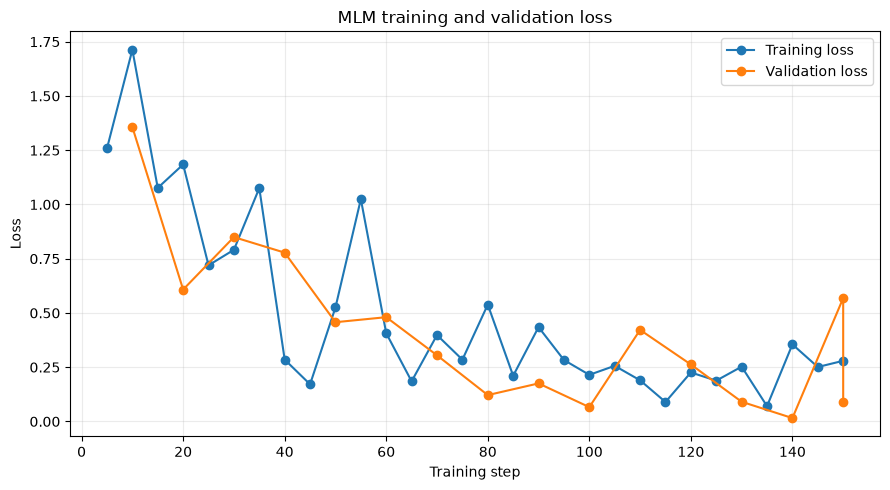

In [42]:
# Separate training and validation records because the Trainer logs them
# at different intervals and therefore at different step coordinates.
train_history = [entry for entry in trainer.state.log_history if 'loss' in entry]
validation_history = [entry for entry in trainer.state.log_history if 'eval_loss' in entry]

plt.figure(figsize=(9, 5))
plt.plot([entry['step'] for entry in train_history],
         [entry['loss'] for entry in train_history], marker='o', label='Training loss')
plt.plot([entry['step'] for entry in validation_history],
         [entry['eval_loss'] for entry in validation_history], marker='o', label='Validation loss')
plt.title('MLM training and validation loss')
plt.xlabel('Training step')
plt.ylabel('Loss')
plt.grid(alpha=.25)
plt.legend()
plt.tight_layout()
plt.show()


### Training and validation loss

The curves below use the trainer's logged step-level losses. Validation points are less frequent because evaluation runs every ten steps.


In [ ]:
# Re-score the identical held-out pairs so the checkpoint is the only
# changed variable in the before/after comparison.
adapted_scores = pair_scores(pairs)
adapted_metrics = summarize(adapted_scores)

metric_names = list(baseline_metrics)
comparison = {
    name: {'base': baseline_metrics[name], 'adapted': adapted_metrics[name],
           'delta': adapted_metrics[name] - baseline_metrics[name]}
    for name in metric_names
}
comparison


# Compare the similarity distributions; useful adaptation should move
# positive pairs rightward relative to negative pairs.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = np.linspace(min(baseline_scores.min(), adapted_scores.min()), 1.0, 20)
axes[0].hist(baseline_scores[labels == 1], bins=bins, alpha=.65, label='positive')
axes[0].hist(baseline_scores[labels == 0], bins=bins, alpha=.65, label='negative')
axes[0].set(title='Original encoder', xlabel='Cosine similarity', ylabel='Pair count')
axes[0].legend()
axes[1].hist(adapted_scores[labels == 1], bins=bins, alpha=.65, label='positive')
axes[1].hist(adapted_scores[labels == 0], bins=bins, alpha=.65, label='negative')
axes[1].set(title='Animal-domain MLM encoder', xlabel='Cosine similarity')
axes[1].legend()
plt.tight_layout()
plt.show()


In [30]:
# Re-score the identical held-out pairs so the checkpoint is the only
# changed variable in the before/after comparison.
adapted_scores = pair_scores(pairs)
adapted_metrics = summarize(adapted_scores)

metric_names = list(baseline_metrics)
comparison = {
    name: {'base': baseline_metrics[name], 'adapted': adapted_metrics[name],
           'delta': adapted_metrics[name] - baseline_metrics[name]}
    for name in metric_names
}
comparison


{'ROC AUC': {'base': 0.66, 'adapted': 0.64, 'delta': -0.020000000000000018},
 'positive similarity': {'base': 0.9256182909011841,
  'adapted': 0.9113920331001282,
  'delta': -0.014226257801055908},
 'negative similarity': {'base': 0.9179766774177551,
  'adapted': 0.8950809240341187,
  'delta': -0.022895753383636475},
 'separation margin': {'base': 0.007641613483428955,
  'adapted': 0.01631110906600952,
  'delta': 0.008669495582580566}}

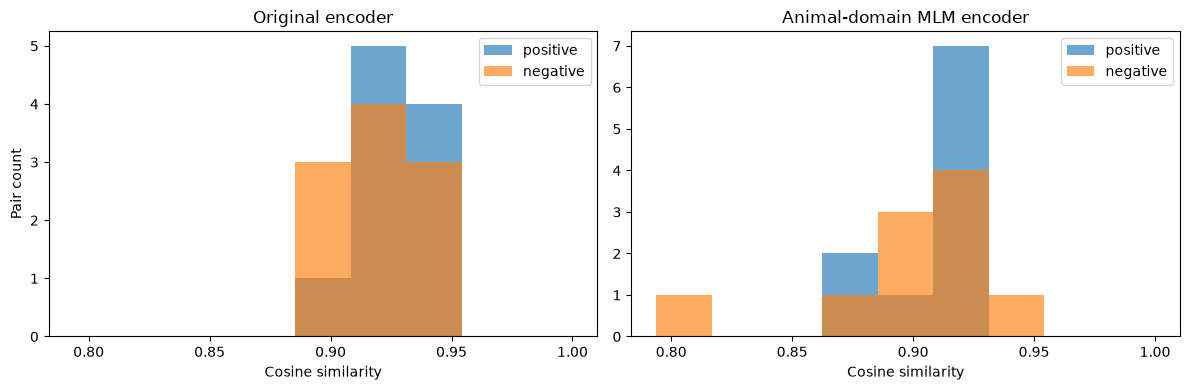

In [31]:
# Embed one neutral probe per species and project the high-dimensional
# vectors to two dimensions. PCA is exploratory, not a quality metric.
species = ['otter', 'camel', 'penguin', 'owl', 'frog', 'turtle', 'bee', 'wolf', 'dolphin', 'eagle', 'beaver', 'octopus']
probe_texts = [f'A field researcher observes a {name} in its natural habitat.' for name in species]
probe_embeddings = embed(probe_texts)
points = PCA(n_components=2).fit_transform(probe_embeddings)

plt.figure(figsize=(9, 6))
plt.scatter(points[:, 0], points[:, 1], s=60)
for name, (x, y) in zip(species, points):
    plt.annotate(name, (x, y), xytext=(4, 4), textcoords='offset points')
plt.title('PCA of adapted animal embeddings (exploratory only)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=.2)
plt.show()


## 7. Visualize the representation space (exploratory)

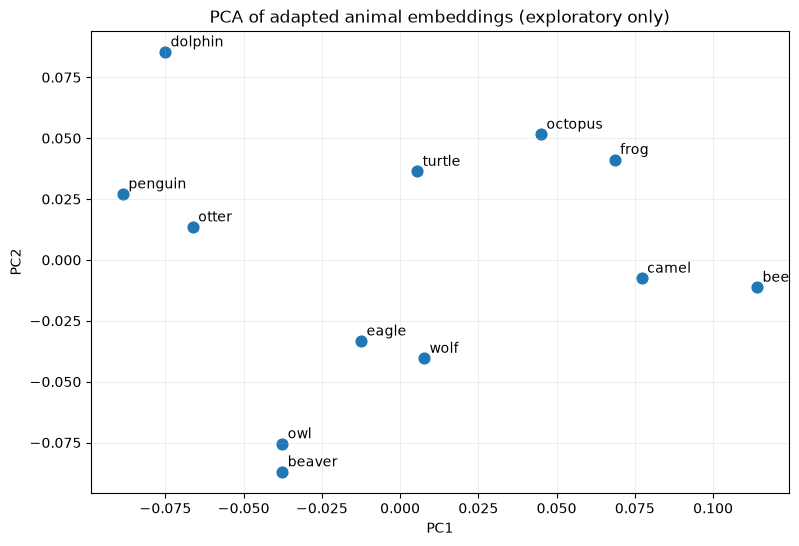

In [32]:
# Require agreement between ranking and separation metrics before making
# a directional claim about this single experimental run.
auc_delta = adapted_metrics['ROC AUC'] - baseline_metrics['ROC AUC']
margin_delta = adapted_metrics['separation margin'] - baseline_metrics['separation margin']
if auc_delta > 0 and margin_delta > 0:
    conclusion = 'Both held-out metrics improved in this run.'
elif auc_delta < 0 and margin_delta < 0:
    conclusion = 'Both held-out metrics declined in this run; adaptation was not beneficial.'
else:
    conclusion = 'The held-out metrics disagree; this run is inconclusive.'
print(conclusion)
print(f'ROC AUC delta: {auc_delta:+.3f}; separation-margin delta: {margin_delta:+.3f}')


## 8. State the result without overclaiming

In [33]:
# Require agreement between ranking and separation metrics before making
# a directional claim about this single experimental run.
auc_delta = adapted_metrics['ROC AUC'] - baseline_metrics['ROC AUC']
margin_delta = adapted_metrics['separation margin'] - baseline_metrics['separation margin']
if auc_delta > 0 and margin_delta > 0:
    conclusion = 'Both held-out metrics improved in this run.'
elif auc_delta < 0 and margin_delta < 0:
    conclusion = 'Both held-out metrics declined in this run; adaptation was not beneficial.'
else:
    conclusion = 'The held-out metrics disagree; this run is inconclusive.'
print(conclusion)
print(f'ROC AUC delta: {auc_delta:+.3f}; separation-margin delta: {margin_delta:+.3f}')


The held-out metrics disagree; this run is inconclusive.
ROC AUC delta: -0.020; separation-margin delta: +0.009


## What would make this portfolio evidence stronger?

- Repeat the base/adapted comparison across at least five seeds and bootstrap confidence intervals.
- Use authentic domain documents and a document-level held-out test set.
- Add Recall@k, MRR, and nDCG on a realistic retrieval task.
- Compare full tuning, LoRA, QLoRA, no adaptation, and a sentence-transformer baseline.
- Evaluate general-domain retention to detect catastrophic forgetting.
- Treat PCA as visualization only; do not infer quality from cluster appearance.